In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn

from celluloid import Camera
import scienceplots
from IPython.display import Image

torch.manual_seed(0)
np.random.seed(0)
plt.style.use(["science", "no-latex"])

In [2]:
from abc import ABC, abstractmethod


class Layer(ABC):
    def __init__(self):
        self.input = None
        self.output = None

    @abstractmethod
    def forward(self, input):
        pass

    @abstractmethod
    def backward(self, output_gradient, learning_rate):
        pass

In [3]:
class Dense(Layer):
    def __init__(self, input_neurons, output_neurons):
        self.weights = np.random.randn(output_neurons, input_neurons)
        self.bias = np.random.randn(output_neurons, 1)

    def forward(self, input):
        self.input = input
        return np.matmul(self.weights, self.input) + self.bias

    def backward(self, output_gradient, learning_rate):
        weights_gradient = np.matmul(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        # Gradient Descent
        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        return input_gradient

In [4]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

    def plot(self, x_min, x_max, points=25):
        x = np.linspace(x_min, x_max, points)
        y = self.activation(x)
        y_prime = self.activation_prime(y)

        fig, axes = plt.subplots(1, 2)
        axes[0].plot(x, y)
        axes[0].set_xlabel("X")
        axes[0].set_ylabel("Y")
        axes[0].set_title("F(X)")

        axes[1].plot(x, y_prime)
        axes[1].set_xlabel("X")
        axes[1].set_ylabel("Y")
        axes[1].set_title("F'(X)")

        fig.show()

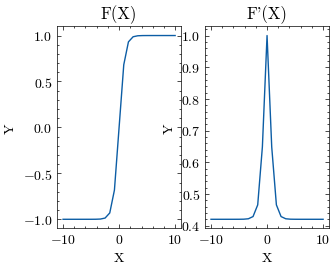

In [5]:
class Tanh(Activation):
    def __init__(self):
        tanh = lambda x: np.tanh(x)
        tanh_prime = lambda x: 1 - np.tanh(x) ** 2
        super().__init__(tanh, tanh_prime)


class ArcTan(Activation):
    def __init__(self):
        arctan = lambda x: np.arctan(x)
        arctan_prime = lambda x: 1 / (1 + np.power(x, 2))
        super().__init__(arctan, arctan_prime)


class Sigmoid(Activation):
    def __init__(self):
        sigmoid = lambda x: 1 / (1 + np.exp(-x))
        sigmoid_prime = lambda x: np.exp(-x) / np.power((1 + np.exp(-x)), 2)
        super().__init__(sigmoid, sigmoid_prime)


class Relu(Activation):
    def __init__(self):
        relu = lambda x: np.maximum(0, x)
        relu_prime = lambda x: np.greater(x, 0).astype(int)
        super().__init__(relu, relu_prime)


class LeakyRelu(Activation):
    def __init__(self):
        relu = lambda x: np.where(x > 0, x, x * 0.1)
        relu_prime = lambda x: np.where(x > 0, 1, 0.01)
        super().__init__(relu, relu_prime)


Tanh().plot(-10, 10)

In [6]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))


def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from celluloid import Camera
from IPython.display import display, Latex, Image


def create_plots():
    fig, ax = plt.subplots(1, 3, figsize=(16 / 9.0 * 4, 4 * 1), layout="constrained")
    fig.suptitle("Neural Network")

    ax[0].set_xlabel("Epoch", fontweight="normal")
    ax[0].set_ylabel("Error", fontweight="normal")
    ax[0].set_title("Mean Squared Error")

    ax[1].axis("off")
    ax[2].axis("off")

    ax[2] = fig.add_subplot(1, 2, 2, projection="3d")
    ax[2].set_xlabel("X")
    ax[2].set_ylabel("Y")
    ax[2].set_zlabel("Z")
    ax[2].set_title("Function Approximation")
    ax[2].view_init(20, -35)

    camera = Camera(fig)
    return ax[0], ax[2], camera

In [8]:
def fit(
    network, features, labels, X, Y, Z, dims, epochs, learning_rate, output_filename
):
    mse_idx = np.arange(1, epochs + 1)
    errors = np.full(epochs, -1)
    ax0, ax1, camera = create_plots()

    for idx in range(epochs):
        error = 0
        predictions = np.array([])

        for x, y in zip(features, labels):
            # Forward Propagation
            output = x
            for layer in network:
                output = layer.forward(output)

            # Store Error
            predictions = np.append(predictions, output)
            error += mse(y, output)

            # Backpropagation
            grad = mse_prime(y, output)
            for layer in reversed(network):
                grad = layer.backward(grad, learning_rate)

        error /= len(X)

        if (
            idx < 5
            or (idx < 15 and idx % 2 == 0)
            or (idx <= 50 and idx % 10 == 0)
            or (idx <= 1000 and idx % 20 == 0)
            or idx % 250 == 0
        ):

            print(f"epoch: {idx}, MSE: {error}")

            # Plot MSE
            errors[idx] = error
            visible_mse = errors != -1
            ax0.plot(
                mse_idx[visible_mse][: idx + 1],
                errors[visible_mse][: idx + 1],
                color="red",
                alpha=0.5,
            )

            # Plot Neural Network Function Approximation
            # Ground truth
            ground_truth_legend = ax1.plot_surface(
                X, Y, Z, color="red", alpha=0.5, label="Ground Truth"
            )
            # Neural Network Predictions
            predictions_legend = ax1.scatter(
                X,
                Y,
                predictions.reshape((dims, dims)),
                color="blue",
                alpha=0.2,
                label="Prediction",
            )
            ax1.legend(
                (ground_truth_legend, predictions_legend),
                ("Ground Truth", "Predictions"),
                loc="upper left",
            )

            camera.snap()

    animation = camera.animate()
    animation.save(output_filename, writer="pillow")
    plt.close()

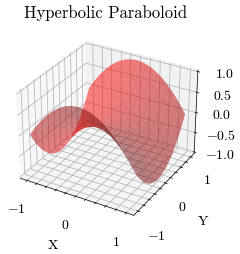

In [9]:
def generate_function(dims):
    a = 1
    b = 1
    c = 1

    # Hyperbolic Paraboloid
    x = np.linspace(-1, 1, dims)
    y = np.linspace(-1, 1, dims)
    X, Y = np.meshgrid(x, y)
    Z = ((Y**2 / b**2) - (X**2 / a**2)) * c

    X_t = X.flatten()
    Y_t = Y.flatten()
    Z_t = Z.flatten()
    X_t = X_t.reshape((len(X_t), 1))
    Y_t = Y_t.reshape((len(Y_t), 1))
    Z_t = Z_t.reshape((len(Z_t), 1))
    features = np.stack((X_t, Y_t), axis=1)
    labels = Z_t.reshape((len(Z_t), 1, 1))

    return X, Y, Z, features, labels


dims = 20
X, Y, Z, features, labels = generate_function(dims)

# Visualize the Hyperbolic Paraboloid
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, color="red", alpha=0.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Hyperbolic Paraboloid")
plt.show()

epoch: 0, MSE: 21.00860848511376
epoch: 1, MSE: 17.5586476607417
epoch: 2, MSE: 11.962836688096
epoch: 3, MSE: 7.68257809360996
epoch: 4, MSE: 5.856178734359532
epoch: 6, MSE: 4.101981960799444
epoch: 8, MSE: 3.239212598337815
epoch: 10, MSE: 2.781463458914172
epoch: 12, MSE: 2.4899978448083546
epoch: 14, MSE: 2.264408395525184
epoch: 20, MSE: 1.746794685353164
epoch: 30, MSE: 1.23779838600893
epoch: 40, MSE: 0.9715469061310487
epoch: 50, MSE: 0.8070032878502758
epoch: 60, MSE: 0.6957056202886597
epoch: 80, MSE: 0.5583020760768337
epoch: 100, MSE: 0.47836451995070384
epoch: 120, MSE: 0.4256256408272474
epoch: 140, MSE: 0.3874577766812147
epoch: 160, MSE: 0.35803563178169423
epoch: 180, MSE: 0.3343283017491935
epoch: 200, MSE: 0.3145830966011098


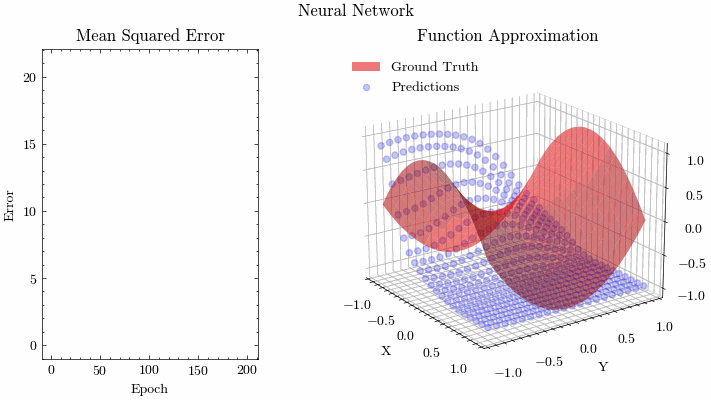

In [10]:
epochs = 201
learning_rate = 0.0005

network = [Dense(2, 12), Tanh(), Dense(12, 4), Tanh(), Dense(4, 1), Tanh()]

output_filename = "neural_network.gif"
fit(network, features, labels, X, Y, Z, dims, epochs, learning_rate, output_filename)

Image(filename=output_filename)